In [129]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [130]:
from util import *
import os
import torch.nn as nn
import numpy as np

# Test Retraining

In [131]:
from cnn import model, input
from cnn.trainer import BaseTrainer  # assuming the code above is saved in trainer.py
from cnn.input import GenericDataLoader
from util import init_log
import copy
import qnas_config as cfg
from cnn import master

In [132]:
LOGGER = init_log("INFO", name=__name__)

In [133]:
phase = 'evolution'
experiment_path = 'my_exp_config3'
config_file = 'config_files_cifar/config3.txt'

args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10_data',
    'log_level': 'INFO',
    'log_level': 'INFO',
    'fitness_metric': 'best_accuracy',
    'optimizer': 'AdamW',
    'data_augmentation': 'True',
    'dataset': 'cifar10',
    'save_checkpoints_epochs': 10,
    'early_stopping': 'False',
    'en_pop_crossover': 'False',
    'network_config': 'backbone',
    'backbone_name': 'resnet18',
    'limit_data_value': 10000,
    'limit_data': 'False',
    'batch_size': 256,
    'eval_batch_size': 256,
    'max_epochs': 200,
    'epochs_to_eval': 200,
    'mixed_precision': False,
    "phase": 'retrain',
    'mo_metric_base': 'loss',
    'max_params': 114090,
    'max_inference_time': 1000,
    'task': 'classification',
    'backbone_percentage': 0.6636407117075649,
    'backbone_trainable': 'True',
    'num_workers': 4,
    'patience_retrain': 25,

}

config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

fn_dict=config.fn_dict
fn_dict_tf = copy.deepcopy(fn_dict)
fn_dict

net_list = ["bv1_3_1_256",
"no_op",
"no_op",
"bv1_5_1_128",
"no_op",
"no_op",
"resv1cbam_3_1_128",
"no_op",
"avg_pool_2_2",
"max_pool_2_2"]
params = config.train_spec

In [134]:
data_loader = GenericDataLoader(params=args)
train_loader, val_loader = data_loader.get_loader(pin_memory_device='cuda:0')

In [135]:
test_loader= data_loader.get_loader(pin_memory_device='cuda:0', for_train=False)

In [136]:
if args['dataset'].lower() in input.available_datasets:
    dataset_info = input.available_datasets[args['dataset'].lower()]
else:
    dataset_info = load_yaml(os.path.join(args['data_path'], 'data_info.txt'))

args['num_classes'] = dataset_info['num_classes']
args['task'] = dataset_info['task']
args['input_shape'] = [args['batch_size']] + dataset_info['shape']
args['device'] = 'cuda:0'
args['fn_dict'] = fn_dict
args['net_list'] = net_list

In [137]:
has_cbam_key = any(key.startswith('cbam') for key in fn_dict)

In [138]:
# Create the model    
model_net = model.NetworkGraph(num_classes=args['num_classes'],
                        input_shape=args['input_shape'],
                        network_config=args['network_config'],
                        backbone_name=args['backbone_name'],
                        backbone_percentage=args['backbone_percentage'],
                        backbone_trainable = True,)

filtered_dict = {key: item for key, item in fn_dict.items() if key in net_list}
model_net.create_functions(fn_dict=filtered_dict, net_list=net_list, cbam=has_cbam_key)

# Add the fully connected layer to the model
input_shape =  [args['batch_size']] + dataset_info['shape']
inputs = torch.randn(input_shape)
with torch.no_grad():
    _ = model_net(inputs)

args['input_shape'] = input_shape

criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.AdamW(model_net.parameters())

# optimizer = torch.optim.AdamW(
#     model_net.parameters(),
#     lr=3e-5,
#     betas=(0.9, 0.999),
#     eps=1e-8,
# )

optimizer = torch.optim.AdamW([{'params': model_net.backbone.parameters(), 'lr': 3e-6, "betas":(0.9, 0.999),"weight_decay":0 },
                                {'params': model_net.model.parameters(), 'lr': 1e-3}])

In [139]:
model_path = os.path.join(args['experiment_path'])
if not os.path.exists(model_path):
    os.makedirs(model_path)

args['model_path'] = model_path

In [140]:
args['phase'] = 'retrain'

In [141]:
trainer = BaseTrainer(model_net, criterion, optimizer, train_loader, val_loader, test_loader, args)
results = trainer.train()

Patience max: 25, base fraction: 0.0050
Best validation loss: 0.9104, Current validation loss: 0.9104
difference: 0.0000, min_delta: 0.0046
Best validation loss: 0.9104, Current validation loss: 0.7992
difference: 0.1113, min_delta: 0.0046
Validation loss improved by more than 0.0046
Best validation loss: 0.7992, Current validation loss: 0.6533
difference: 0.1458, min_delta: 0.0040
Validation loss improved by more than 0.0040
Best validation loss: 0.6533, Current validation loss: 0.6167
difference: 0.0367, min_delta: 0.0033
Validation loss improved by more than 0.0033
Best validation loss: 0.6167, Current validation loss: 0.6013
difference: 0.0154, min_delta: 0.0031
Validation loss improved by more than 0.0031
Best validation loss: 0.6013, Current validation loss: 0.5881
difference: 0.0132, min_delta: 0.0030
Validation loss improved by more than 0.0030
Best validation loss: 0.5881, Current validation loss: 0.5609
difference: 0.0273, min_delta: 0.0029
Validation loss improved by more th

In [142]:
keys = list(results.keys())

In [146]:
print(f"Test Accuracy: {results['test_accuracy']}")

Test Accuracy: 84.8


In [143]:
print(f"Test Accuracy: {results['test_accuracy']}")

Test Accuracy: 84.8


In [147]:
total_epochs = len(results['training_losses'])
total_epochs

47

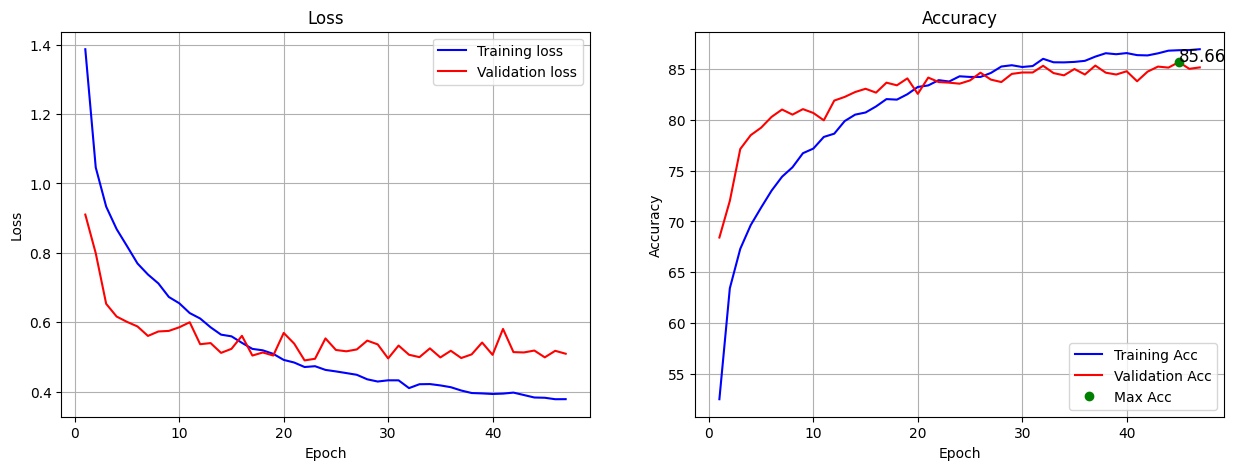

In [148]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
results_dict = results[list(results.keys())[0]]
epochs = range(1, len(results['training_losses']) + 1)
ax[0].plot(epochs, results["training_losses"], 'b', label='Training loss')
ax[0].plot(epochs, results["validation_losses"], 'r', label='Validation loss')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(epochs, results["training_accuracies"], 'b', label='Training Acc')
ax[1].plot(epochs, results["validation_accuracies"], 'r', label='Validation Acc')
max_acc, index = max(results["validation_accuracies"]), results["validation_accuracies"].index(max(results["validation_accuracies"]))
ax[1].plot(index+1, max_acc, 'go', label='Max Acc')
ax[1].text(index+1, max_acc+0.1, f'{max_acc:.2f}', fontsize=12)
ax[1].set_title('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)